In [1]:
# ----------------------------
# Clean + aggregate Generic Keywords (GKs) by Basic Type
# Input : New_BT_GKs_Raw.csv (2 columns: "Basic Type", "Generic keywords")
# Output: New_BT_GKs_Cleaned_Unique.csv (2 columns: "Basic Type", "GKs")
#         where GKs is a Python-list-like string using single quotes:
#         ['kw1', 'kw2', ...]
# ----------------------------

import os
import re
import pandas as pd
from collections import OrderedDict

# ---------- 1) Locate input CSV (works in fresh notebooks) ----------
candidate_paths = [
    os.path.abspath("../Data/New_BT_GKs_Raw.csv"),        # relative to project root
    os.path.expanduser("~/Data/New_BT_GKs_Raw.csv"),   # user said home directory
    "/mnt/data/Data/New_BT_GKs_Raw.csv",               # common sandbox path
]

input_path = None
for p in candidate_paths:
    if os.path.exists(p):
        input_path = p
        break

if input_path is None:
    raise FileNotFoundError(
        "Couldn't find New_BT_GKs_Raw.csv. Tried:\n" + "\n".join(candidate_paths)
    )

print("✅ Reading:", input_path)

# ---------- 2) Read CSV robustly ----------
# (handles extra columns; we only keep the first two if needed)
df = pd.read_csv(input_path)

# Normalize column names (strip spaces)
df.columns = [c.strip() for c in df.columns]

# Try to find the required columns even if capitalization differs
def find_col(df_cols, target):
    target_norm = re.sub(r"\s+", " ", target.strip().lower())
    for c in df_cols:
        c_norm = re.sub(r"\s+", " ", c.strip().lower())
        if c_norm == target_norm:
            return c
    return None

bt_col = find_col(df.columns, "Basic Type")
gk_col = find_col(df.columns, "Generic keywords")

# If not found, fallback to first two columns
if bt_col is None or gk_col is None:
    if len(df.columns) < 2:
        raise ValueError("CSV must have at least 2 columns for Basic Type and Generic keywords.")
    bt_col, gk_col = df.columns[0], df.columns[1]
    print(f"⚠️ Column names not matched. Falling back to first two columns: {bt_col!r}, {gk_col!r}")
else:
    print(f"✅ Using columns: {bt_col!r}, {gk_col!r}")

df = df[[bt_col, gk_col]].copy()
df.rename(columns={bt_col: "Basic Type", gk_col: "Generic keywords"}, inplace=True)

# ---------- 3) Cleaning helpers ----------
def normalize_basic_type(x: str) -> str:
    if pd.isna(x):
        return ""
    # collapse whitespace + strip
    s = re.sub(r"\s+", " ", str(x)).strip()
    return s

def split_keywords(cell) -> list[str]:
    """
    Split a cell like:
      "Ceregrow, Baby Care, Baby Cereal, Nestle Ceregrow"
    into a list of cleaned keyword strings.
    """
    if pd.isna(cell):
        return []
    s = str(cell)

    # common cleanup: normalize whitespace
    s = re.sub(r"\s+", " ", s).strip()

    # split on commas (simple + matches your sample)
    parts = [p.strip() for p in s.split(",")]

    # remove empties + normalize internal whitespace
    cleaned = []
    for p in parts:
        p2 = re.sub(r"\s+", " ", p).strip()
        if p2 != "":
            cleaned.append(p2)
    return cleaned

def ordered_unique_case_insensitive(items: list[str]) -> list[str]:
    """
    De-dup keywords case-insensitively while preserving first-seen order.
    Keeps the original casing of the first occurrence.
    """
    seen = set()
    out = []
    for it in items:
        key = it.casefold()
        if key not in seen:
            seen.add(key)
            out.append(it)
    return out

def to_single_quote_list_literal(items: list[str]) -> str:
    """
    Convert list -> string in format:
      ['a', 'b', 'c']
    Escapes single quotes inside items.
    """
    escaped = [i.replace("\\", "\\\\").replace("'", "\\'") for i in items]
    return "[" + ", ".join([f"'{i}'" for i in escaped]) + "]"

# ---------- 4) Clean + aggregate ----------
df["Basic Type"] = df["Basic Type"].map(normalize_basic_type)
df["Generic keywords"] = df["Generic keywords"].astype("string")

# Drop blank Basic Types
df = df[df["Basic Type"].ne("")].copy()

# Build aggregation with stable ordering:
# - preserve Basic Type order as first appearance in the file
# - preserve GK order as first appearance across that Basic Type
basic_type_order = df["Basic Type"].drop_duplicates().tolist()

gks_by_bt: dict[str, list[str]] = OrderedDict((bt, []) for bt in basic_type_order)

for bt, cell in zip(df["Basic Type"], df["Generic keywords"]):
    gks_by_bt[bt].extend(split_keywords(cell))

# De-dup per basic type
rows = []
for bt, gks in gks_by_bt.items():
    uniq_gks = ordered_unique_case_insensitive(gks)
    rows.append(
        {
            "Basic Type": bt,
            "GKs": to_single_quote_list_literal(uniq_gks),
            "_gk_count": len(uniq_gks),  # helper column for inspection (will drop before saving)
        }
    )

out_df = pd.DataFrame(rows)

# Optional: sort by Basic Type (comment out if you want original order)
# out_df = out_df.sort_values("Basic Type", kind="stable").reset_index(drop=True)

# ---------- 5) Save output ----------
input_dir = os.path.dirname(input_path) or "."
output_path = os.path.join(input_dir, "New_BT_GKs_Cleaned_Unique.csv")

out_df_to_save = out_df.drop(columns=["_gk_count"])
out_df_to_save.to_csv(output_path, index=False, encoding="utf-8")

print("✅ Saved:", output_path)

# ---------- 6) Quick sanity checks / preview ----------
print("\nPreview (first 20 rows):")
display(out_df_to_save.head(20))

print("\nTop 10 Basic Types by GK count:")
display(out_df.sort_values("_gk_count", ascending=False).head(10)[["Basic Type", "_gk_count"]])

✅ Reading: c:\Code\AI Tagging\Data\New_BT_GKs_Raw.csv
✅ Using columns: 'Basic Type', 'Generic keywords'
✅ Saved: c:\Code\AI Tagging\Data\New_BT_GKs_Cleaned_Unique.csv

Preview (first 20 rows):


,Basic Type,GKs
0,Baby Cereal,"['Cereal', 'Baby Care', 'Baby Cereal', '1 to 3..."
1,Baby Milk Powder,"['Pediapro', 'Baby Care', 'Baby Formula', 'Anc..."
2,Baby Rusk,"['Biscuit', 'Baby Rusk', 'Groceries', 'Orange ..."
3,Baby Detergent Liquid,"['Baby Care', 'Baby Laundry', 'Baby Detergent'..."
4,Baby Body Wash,"['Baby Care', 'Baby Body Wash', 'Wild Berries ..."
5,Baby Bottle Brush,"['Baby Care', 'Baby Bottle Brush', 'Farlin Bot..."
6,Baby Cloth Pegs,"['Baby Care', 'Cloth Pegs', 'Baby Cloth Pegs',..."
7,Baby Cologne,"['Cologne', 'Baby Care', 'Baby Cologne', 'Flor..."
8,Baby Cotton Buds,"['Baby Care', 'Baby Cotton Buds', 'Kids Joy Co..."
9,Baby Cream,"['Baby Care', 'Baby Cream', 'Kates Choice Baby..."



Top 10 Basic Types by GK count:


,Basic Type,_gk_count
82,Biscuit,267
318,Ice Cream Tub,226
84,Chocolate,204
61,Shampoo,172
348,Face Wash,148
483,Pasta,144
680,Sausage,127
374,Perfume,105
75,Instant Coffee,104
728,Soya Meat,101


In [2]:
import os
import pandas as pd
import numpy as np

# =========================
# CONFIG (edit these)
# =========================
N_SAMPLE = 50                 # total number of SKU rows you want in the test sample
RANDOM_SEED = 42               # reproducible randomness
MIN_PER_CATEGORY = 1           # ensure at least this many rows per category (if possible)
MAX_PER_CATEGORY = None        # optionally cap rows per category (e.g., 200). Keep None to disable.
CATEGORY_COL = "Categories"    # column name in Catalog_SKUs.csv
NAME_COL = "Name"              # column name in Catalog_SKUs.csv

# Input path: 'Testing Data/Catalog_SKUs.csv'
candidate_paths = [
    os.path.join("Testing Data", "Catalog_SKUs.csv"),
    os.path.expanduser("~/Testing Data/Catalog_SKUs.csv"),
    os.path.abspath(os.path.join("Testing Data", "Catalog_SKUs.csv")),
    "/mnt/data/Testing Data/Catalog_SKUs.csv",
    "/mnt/data/Testing_Data/Catalog_SKUs.csv",
]

input_path = next((p for p in candidate_paths if os.path.exists(p)), None)
if input_path is None:
    raise FileNotFoundError(
        "Couldn't find Catalog_SKUs.csv. Tried:\n" + "\n".join(candidate_paths)
    )

print("✅ Reading:", input_path)

# =========================
# LOAD + CLEAN
# =========================
df = pd.read_csv(input_path)
df.columns = [c.strip() for c in df.columns]

if CATEGORY_COL not in df.columns or NAME_COL not in df.columns:
    raise ValueError(
        f"Expected columns '{NAME_COL}' and '{CATEGORY_COL}'. "
        f"Found: {list(df.columns)}"
    )

# Drop empty category/name rows
df = df.copy()
df[CATEGORY_COL] = df[CATEGORY_COL].astype("string").fillna("").str.strip()
df[NAME_COL] = df[NAME_COL].astype("string").fillna("").str.strip()
df = df[(df[CATEGORY_COL] != "") & (df[NAME_COL] != "")].reset_index(drop=True)

# If Categories contains multiple values separated by comma/pipe/etc.,
# normalize by taking the FIRST category as the sampling stratum.
# (Adjust split regex if your Categories column uses a different delimiter.)
df["_category_stratum"] = df[CATEGORY_COL].str.split(r"\s*[,|/]\s*", regex=True).str[0].str.strip()
df["_category_stratum"] = df["_category_stratum"].replace("", np.nan)
df = df.dropna(subset=["_category_stratum"]).reset_index(drop=True)

total_available = len(df)
if N_SAMPLE > total_available:
    print(f"⚠️ Requested N_SAMPLE={N_SAMPLE} but only {total_available} rows available. Using all rows.")
    N_SAMPLE = total_available

# =========================
# STRATIFIED SAMPLING LOGIC
# - Base: proportional to category sizes
# - Enforce MIN_PER_CATEGORY where possible
# - Optionally enforce MAX_PER_CATEGORY
# - Fill remainder by weighted sampling from remaining rows
# =========================
rng = np.random.default_rng(RANDOM_SEED)

cat_counts = df["_category_stratum"].value_counts()
cats = cat_counts.index.tolist()
k = len(cats)

# If N_SAMPLE is too small to satisfy MIN_PER_CATEGORY across all categories,
# reduce the effective min to fit.
effective_min = MIN_PER_CATEGORY
if k * effective_min > N_SAMPLE:
    effective_min = N_SAMPLE // k
    print(f"⚠️ N_SAMPLE too small for MIN_PER_CATEGORY={MIN_PER_CATEGORY} across {k} categories.")
    print(f"   Using effective MIN_PER_CATEGORY={effective_min}.")

# Initial allocation: proportional
proportions = cat_counts / cat_counts.sum()
alloc = (proportions * N_SAMPLE).round().astype(int)

# Enforce min where feasible
if effective_min > 0:
    alloc = alloc.clip(lower=effective_min)

# Enforce max if provided
if MAX_PER_CATEGORY is not None:
    alloc = alloc.clip(upper=int(MAX_PER_CATEGORY))

# Cap each category allocation to available rows in that category
alloc = pd.Series(
    {c: min(int(alloc.get(c, 0)), int(cat_counts[c])) for c in cats}
)

# Adjust total to exactly N_SAMPLE
current_total = int(alloc.sum())

def take_from_categories(alloc_series, needed):
    """Reduce allocation (if needed < 0) from categories with slack > 0."""
    if needed >= 0:
        return alloc_series

    needed = -needed
    # Reduce from categories that are above effective_min (or above 0 if effective_min is 0)
    floor = effective_min if effective_min > 0 else 0
    reducible = alloc_series - floor
    reducible = reducible[reducible > 0].sort_values(ascending=False)

    for c in reducible.index:
        if needed == 0:
            break
        dec = min(int(reducible[c]), needed)
        alloc_series[c] -= dec
        needed -= dec

    return alloc_series

def add_to_categories(alloc_series, needed):
    """Increase allocation up to availability (and MAX_PER_CATEGORY if set)."""
    if needed <= 0:
        return alloc_series

    # Remaining capacity per category
    cap = pd.Series({c: int(cat_counts[c]) for c in cats}) - alloc_series
    if MAX_PER_CATEGORY is not None:
        cap = np.minimum(cap, int(MAX_PER_CATEGORY) - alloc_series)
    cap = cap[cap > 0]

    # Distribute additions proportional to remaining capacity
    if cap.empty:
        return alloc_series

    cap_props = cap / cap.sum()
    add = (cap_props * needed).round().astype(int)

    # Ensure we don't add more than capacity
    for c in add.index:
        add[c] = min(int(add[c]), int(cap[c]))

    # Fix rounding mismatch by greedy filling
    added = int(add.sum())
    remainder = needed - added

    alloc_series.loc[add.index] += add

    if remainder > 0:
        cap2 = pd.Series({c: int(cat_counts[c]) for c in cats}) - alloc_series
        if MAX_PER_CATEGORY is not None:
            cap2 = np.minimum(cap2, int(MAX_PER_CATEGORY) - alloc_series)
        cap2 = cap2[cap2 > 0].sort_values(ascending=False)

        for c in cap2.index:
            if remainder == 0:
                break
            alloc_series[c] += 1
            remainder -= 1

    return alloc_series

# First pass: fix over/under allocation to match N_SAMPLE
alloc = take_from_categories(alloc.copy(), current_total - N_SAMPLE)
alloc = add_to_categories(alloc.copy(), N_SAMPLE - int(alloc.sum()))
final_total = int(alloc.sum())

# If still not exact (rare corner cases), fallback to simple global sample
if final_total != N_SAMPLE:
    print(f"⚠️ Allocation could not reach exact N_SAMPLE. Falling back to simple random sample of {N_SAMPLE}.")
    sampled_df = df.sample(n=N_SAMPLE, random_state=RANDOM_SEED).drop(columns=["_category_stratum"])
else:
    # Sample per category
    parts = []
    for c, n in alloc.items():
        if n <= 0:
            continue
        sub = df[df["_category_stratum"] == c]
        parts.append(sub.sample(n=n, random_state=int(rng.integers(0, 2**31 - 1))))
    sampled_df = pd.concat(parts, ignore_index=True)

    # Shuffle final sample
    sampled_df = sampled_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
    sampled_df = sampled_df.drop(columns=["_category_stratum"])

# =========================
# SAVE OUTPUT FILES
# =========================
out_dir = os.path.dirname(input_path) or "."
sample_csv_path = os.path.join(out_dir, f"Catalog_SKUs_TestSample_{N_SAMPLE}.csv")
names_csv_path = os.path.join(out_dir, f"Catalog_SKUs_TestSample_{N_SAMPLE}_NamesOnly.csv")

sampled_df.to_csv(sample_csv_path, index=False, encoding="utf-8")

# Names-only file (one column: Name)
sampled_df[[NAME_COL]].to_csv(names_csv_path, index=False, encoding="utf-8")

print("✅ Saved sample file:", sample_csv_path)
print("✅ Saved names-only file:", names_csv_path)

# =========================
# QUICK DISTRIBUTION CHECK
# =========================
dist = sampled_df[CATEGORY_COL].astype("string").fillna("").str.split(r"\s*[,|/]\s*", regex=True).str[0].str.strip()
dist = dist.value_counts().rename_axis("Category").reset_index(name="count")

print("\nSample distribution (by first category token):")
display(dist.head(30))
print(f"\nTotal sampled rows: {len(sampled_df)}")

✅ Reading: Testing Data\Catalog_SKUs.csv
⚠️ Allocation could not reach exact N_SAMPLE. Falling back to simple random sample of 50.
✅ Saved sample file: Testing Data\Catalog_SKUs_TestSample_50.csv
✅ Saved names-only file: Testing Data\Catalog_SKUs_TestSample_50_NamesOnly.csv

Sample distribution (by first category token):


,Category,count
0,Groceries,25
1,Personal Care,9
2,Dairy,6
3,Baby Care,3
4,Frozen Foods,2
5,Household,2
6,Stationery,1
7,Poultry and Meat,1
8,Fresh Produce,1



Total sampled rows: 50


# 🧪 Automated Multi-Approach SKU Tagging Benchmark

This section automates the **full tagging pipeline** (Category + Basic Type + Generic Keywords) using multiple approaches and models, then compares **accuracy vs. cost**.

### Approaches tested:
1. **GPT "BT + Category"** — Sends all ~1.2k basic types to GPT in one batch (current Streamlit method)
2. **Embedding + GPT** — Uses embedding similarity to shortlist candidate BTs, then GPT picks the best
3. **OpenRouter Models** — Tests the same prompts through various OpenRouter-hosted models

### How to add a new approach:
Register it with `register_approach(name, fn, description)` — see examples below.

In [3]:
# =============================================================================
# CELL 1: Configuration & Environment Setup
# =============================================================================
import os
import json
import time
import pickle
import hashlib
import requests
import numpy as np
import pandas as pd
from datetime import datetime
from dotenv import load_dotenv
from collections import OrderedDict
from dataclasses import dataclass, field, asdict
from typing import Callable, Optional

# Load environment variables (force reload to pick up changes)
load_dotenv(override=True)

# ---------- Azure OpenAI Config ----------
AZURE_API_KEY = os.getenv('AZURE_OPENAI_API_KEY')
AZURE_API_VERSION = os.getenv('AZURE_OPENAI_API_VERSION', '2024-02-01')
AZURE_ENDPOINT = os.getenv('AZURE_OPENAI_ENDPOINT')
AZURE_DEPLOYMENT = os.getenv('AZURE_OPENAI_DEPLOYMENT_NAME')
AZURE_EMBEDDING_DEPLOYMENT = os.getenv('AZURE_OPENAI_EMBEDDING_DEPLOYMENT', '')

# ---------- OpenRouter Config ----------
OPENROUTER_API_KEY = os.getenv('OPENROUTER_API_KEY', '')
OPENROUTER_BASE_URL = "https://openrouter.ai/api/v1"

# Free models with large context windows (latency not a priority)
OPENROUTER_MODELS = [
    {"id": "openrouter/auto",                                "label": "OpenRouter Auto (Free)",      "input_per_1k": 0.0, "output_per_1k": 0.0},
    {"id": "google/gemma-3-27b-it:free",                     "label": "Gemma 3 27B (Free)",          "input_per_1k": 0.0, "output_per_1k": 0.0},
    {"id": "google/gemma-3-12b-it:free",                     "label": "Gemma 3 12B (Free)",          "input_per_1k": 0.0, "output_per_1k": 0.0},
    {"id": "meta-llama/llama-3.3-70b-instruct:free",         "label": "Llama 3.3 70B (Free)",        "input_per_1k": 0.0, "output_per_1k": 0.0},
    {"id": "qwen/qwen3-235b-a22b:free",                      "label": "Qwen 3 235B MoE (Free)",      "input_per_1k": 0.0, "output_per_1k": 0.0},
    {"id": "mistralai/mistral-small-3.1-24b-instruct:free",  "label": "Mistral Small 3.1 24B (Free)","input_per_1k": 0.0, "output_per_1k": 0.0},
    {"id": "deepseek/deepseek-chat-v3-0324:free",            "label": "DeepSeek V3 (Free)",          "input_per_1k": 0.0, "output_per_1k": 0.0},
]

# ---------- Google Sheets (mapping data) ----------
SPREADSHEET_ID = "1-1DejLMWTf7YbUNKVa84fIiguL1XXb14wKJ-w28yOh4"
SHEET_IDS = {"BT_GK_mappings": "1433148032", "BT_CT_mappings": "1757740042"}

# ---------- Test Config ----------
TEST_SAMPLE_FILE = "Catalog_SKUs_TestSample_50.csv"   # ground-truth file with Name, Categories, Basic Type, Generic keywords
TESTING_DATA_DIR = os.path.join(os.getcwd(), "Testing Data")

# Results cache file — so completed approaches aren't re-run
RESULTS_CACHE_PATH = os.path.join(TESTING_DATA_DIR, "benchmark_results_cache.pkl")

# Batch sizes
CATEGORY_BATCH_SIZE = 30
BT_CATEGORY_BATCH_SIZE = 15
EMBEDDING_TOP_K = 30
EMBEDDING_BT_BATCH_SIZE = 15

print("✅ Config loaded")
print(f"   Azure endpoint: {AZURE_ENDPOINT}")
print(f"   Azure deployment: {AZURE_DEPLOYMENT}")
print(f"   Embedding deployment: {AZURE_EMBEDDING_DEPLOYMENT or '(not set)'}")
print(f"   OpenRouter key: {'set' if OPENROUTER_API_KEY else 'NOT SET'}")
print(f"   OpenRouter models: {len(OPENROUTER_MODELS)}")
print(f"   Results cache: {RESULTS_CACHE_PATH}")
print(f"   Test sample: {TEST_SAMPLE_FILE}")
for m in OPENROUTER_MODELS:
    print(f"     - {m['label']} ({m['id']})")

✅ Config loaded
   Azure endpoint: https://oai-pickme-test-dev-sweedencentral-001.openai.azure.com/
   Azure deployment: aoi-pickme-4o-driverReg-dev-001
   Embedding deployment: text-embedding-ada-002
   OpenRouter key: set
   OpenRouter models: 7
   Results cache: c:\Code\AI Tagging\streamlit_app\Testing Data\benchmark_results_cache.pkl
   Test sample: Catalog_SKUs_TestSample_50.csv
     - OpenRouter Auto (Free) (openrouter/auto)
     - Gemma 3 27B (Free) (google/gemma-3-27b-it:free)
     - Gemma 3 12B (Free) (google/gemma-3-12b-it:free)
     - Llama 3.3 70B (Free) (meta-llama/llama-3.3-70b-instruct:free)
     - Qwen 3 235B MoE (Free) (qwen/qwen3-235b-a22b:free)
     - Mistral Small 3.1 24B (Free) (mistralai/mistral-small-3.1-24b-instruct:free)
     - DeepSeek V3 (Free) (deepseek/deepseek-chat-v3-0324:free)


In [4]:
# =============================================================================
# CELL 2: Load Reference Data (Google Sheets mappings + test sample)
# =============================================================================

def load_google_sheet(spreadsheet_id, sheet_gid):
    """Load a Google Sheet as a pandas DataFrame."""
    url = f"https://docs.google.com/spreadsheets/d/{spreadsheet_id}/export?format=csv&gid={sheet_gid}"
    return pd.read_csv(url)

def safe_parse_list(value):
    """Safely parse a string representation of a list."""
    if pd.isna(value) or value is None or not isinstance(value, str):
        return value
    if value.startswith('[') or value.startswith('{'):
        try:
            return json.loads(value.replace("'", '"'))
        except Exception:
            try:
                import ast
                return ast.literal_eval(value)
            except Exception:
                return value
    return value

# --- Load BT <-> Category mapping ---
print("Loading BT_CT_mappings...")
mapping_cat_bt_df = load_google_sheet(SPREADSHEET_ID, SHEET_IDS['BT_CT_mappings'])
for col in mapping_cat_bt_df.columns:
    if mapping_cat_bt_df[col].dtype == object:
        mapping_cat_bt_df[col] = mapping_cat_bt_df[col].apply(safe_parse_list)
print(f"  ✅ {len(mapping_cat_bt_df)} BT-CT records, columns: {list(mapping_cat_bt_df.columns)}")

# --- Load BT <-> GK mapping ---
print("Loading BT_GK_mappings...")
mapping_bt_gk_df = load_google_sheet(SPREADSHEET_ID, SHEET_IDS['BT_GK_mappings'])
for col in mapping_bt_gk_df.columns:
    if mapping_bt_gk_df[col].dtype == object:
        mapping_bt_gk_df[col] = mapping_bt_gk_df[col].apply(safe_parse_list)
print(f"  ✅ {len(mapping_bt_gk_df)} BT-GK records, columns: {list(mapping_bt_gk_df.columns)}")

# --- Derived lookups ---
all_basic_types = mapping_cat_bt_df.iloc[:, 0].unique().tolist()
category_list = mapping_cat_bt_df.iloc[:, 1].unique().tolist()

bt_to_category = {}
for _, row in mapping_cat_bt_df.iterrows():
    bt_to_category[row.iloc[0]] = row.iloc[1]

# Category -> [basic types]
category_to_bts = {}
for bt, cat in bt_to_category.items():
    category_to_bts.setdefault(cat, []).append(bt)

print(f"  ✅ {len(all_basic_types)} unique basic types across {len(category_list)} categories")

# --- Load ground-truth test sample ---
sample_path = os.path.join(TESTING_DATA_DIR, TEST_SAMPLE_FILE)
ground_truth_df = pd.read_csv(sample_path)
ground_truth_df.columns = [c.strip() for c in ground_truth_df.columns]
sku_names = ground_truth_df['Name'].tolist()

print(f"\n✅ Ground-truth sample loaded: {len(sku_names)} SKUs from {TEST_SAMPLE_FILE}")
display(ground_truth_df.head())

Loading BT_CT_mappings...
  ✅ 1287 BT-CT records, columns: ['Basic Tag Type', 'Category Tag Type']
Loading BT_GK_mappings...
  ✅ 1243 BT-GK records, columns: ['Basic Type', 'GKs']
  ✅ 1243 unique basic types across 15 categories

✅ Ground-truth sample loaded: 50 SKUs from Catalog_SKUs_TestSample_50.csv


,Name,Categories,Basic Type,Generic keywords
0,Fontana Pomegranate Juice 1l,Groceries,Fruit Drink,", Juice, Fontana, Groceries, Fruit Drink, Pome..."
1,Kids Joy Baby Lanundry Detergent 1l,Baby Care,Baby Detergent Liquid,"Baby Care, Baby Detergent Liquid, Kids Joy Bab..."
2,Marvel Lady Tampons 10s,Personal Care,Tampons,"Tampons, Personal Care, Marvel Tampons, Marvel..."
3,Keells Krest Jumbo Peanut Chilli 100G,Groceries,Peanuts,"Nuts, Peanuts, Groceries, Jumbo Peanuts, Keels..."
4,Finch Gourment Turkish Dried Figs 75g,Groceries,Dried Fruit,"Groceries, Dried Figs, Dried Fruit, Finch Drie..."


In [5]:
# =============================================================================
# CELL 3: Approach Registry & Shared Utilities
# =============================================================================
from openai import AzureOpenAI
from utils import (
    batch_basictype_category_prompt,
    batch_embedding_bt_category_prompt,
    generic_keyword_prompt,
    calculate_cost,
)
from embedding_utils import (
    build_bt_embeddings,
    get_sku_embeddings,
    find_similar_basic_types_batch,
)

# ---- Result data structures ----
@dataclass
class ApproachResult:
    """Stores results for one approach run."""
    approach_name: str
    description: str
    model_label: str
    # Per-SKU results: list of dicts with keys: sku_name, category, basic_type, generic_keywords
    predictions: list = field(default_factory=list)
    # Cost tracking
    total_tokens: int = 0
    prompt_tokens: int = 0
    completion_tokens: int = 0
    total_cost: float = 0.0
    embedding_cost: float = 0.0
    gpt_cost: float = 0.0
    elapsed_seconds: float = 0.0
    errors: list = field(default_factory=list)

# ---- Registry ----
APPROACH_REGISTRY: dict[str, dict] = OrderedDict()

def register_approach(name: str, fn: Callable, description: str = ""):
    """
    Register a tagging approach.

    `fn` signature: fn(sku_names: list[str]) -> ApproachResult
    It receives the list of SKU names and must return an ApproachResult.
    """
    APPROACH_REGISTRY[name] = {"fn": fn, "description": description}
    print(f"  📌 Registered approach: {name}")

# ---- Shared helper: call Azure OpenAI ----
def azure_gpt_call(prompt: str, deployment: str = None) -> tuple[str, dict]:
    """Call Azure OpenAI and return (response_text, usage_stats)."""
    client = AzureOpenAI(
        api_key=AZURE_API_KEY,
        api_version=AZURE_API_VERSION,
        azure_endpoint=AZURE_ENDPOINT,
    )
    dep = deployment or AZURE_DEPLOYMENT
    completion = client.chat.completions.create(
        model=dep,
        messages=[{"role": "system", "content": prompt}],
    )
    text = completion.choices[0].message.content
    usage = completion.usage
    cost = calculate_cost(usage.prompt_tokens, usage.completion_tokens, dep)
    stats = {
        "prompt_tokens": usage.prompt_tokens,
        "completion_tokens": usage.completion_tokens,
        "total_tokens": usage.total_tokens,
        **cost,
    }
    return text, stats

# ---- Rate-limit config for OpenRouter free tier ----
OPENROUTER_CALL_DELAY = 8        # seconds to wait between consecutive API calls (free tier ≈ 10 req/min)
OPENROUTER_MAX_RETRIES = 10      # generous retries for free-tier rate limits
OPENROUTER_INITIAL_BACKOFF = 8   # initial backoff in seconds (doubles each retry)
OPENROUTER_MODEL_COOLDOWN = 15   # seconds to wait before starting a new model (lets rate limits reset)
OPENROUTER_MAX_CONSECUTIVE_429 = 5  # bail out of a model after N consecutive 429 errors

# ---- Shared helper: call OpenRouter (with retries + rate-limit awareness) ----
_openrouter_last_call_time = 0.0  # tracks when we last called the API
_openrouter_consecutive_429 = 0   # tracks consecutive 429 errors for bail-out logic

def openrouter_call(prompt: str, model_id: str, input_per_1k: float, output_per_1k: float, max_retries: int = None) -> tuple[str, dict]:
    """Call an OpenRouter model with retry logic and rate-limit pacing. Returns (response_text, usage_stats)."""
    global _openrouter_last_call_time, _openrouter_consecutive_429

    if max_retries is None:
        max_retries = OPENROUTER_MAX_RETRIES

    headers = {
        "Authorization": f"Bearer {OPENROUTER_API_KEY}",
        "Content-Type": "application/json",
        "HTTP-Referer": "https://sku-tagging-benchmark.local",
    }
    payload = {
        "model": model_id,
        "messages": [{"role": "system", "content": prompt}],
    }

    # Pace calls: wait at least OPENROUTER_CALL_DELAY seconds between requests
    elapsed_since_last = time.time() - _openrouter_last_call_time
    if elapsed_since_last < OPENROUTER_CALL_DELAY:
        wait_for = OPENROUTER_CALL_DELAY - elapsed_since_last
        time.sleep(wait_for)

    last_error = None
    for attempt in range(1, max_retries + 1):
        try:
            _openrouter_last_call_time = time.time()
            resp = requests.post(f"{OPENROUTER_BASE_URL}/chat/completions", headers=headers, json=payload, timeout=180)
            resp.raise_for_status()
            data = resp.json()

            # Check for OpenRouter-level errors
            if "error" in data:
                raise ValueError(f"OpenRouter error: {data['error']}")

            text = data["choices"][0]["message"]["content"]
            usage = data.get("usage", {})
            pt = usage.get("prompt_tokens", 0)
            ct = usage.get("completion_tokens", 0)
            stats = {
                "prompt_tokens": pt,
                "completion_tokens": ct,
                "total_tokens": pt + ct,
                "input_cost": (pt / 1000) * input_per_1k,
                "output_cost": (ct / 1000) * output_per_1k,
                "total_cost": (pt / 1000) * input_per_1k + (ct / 1000) * output_per_1k,
            }
            # Success — reset consecutive 429 counter
            _openrouter_consecutive_429 = 0
            return text, stats
        except Exception as e:
            last_error = e
            is_429 = "429" in str(e)
            if is_429:
                _openrouter_consecutive_429 += 1
                if _openrouter_consecutive_429 >= OPENROUTER_MAX_CONSECUTIVE_429:
                    print(f"    🚫 {OPENROUTER_MAX_CONSECUTIVE_429} consecutive 429s — skipping model {model_id}")
                    raise RuntimeError(f"Skipping {model_id}: hit {OPENROUTER_MAX_CONSECUTIVE_429} consecutive 429 rate limits") from e

            if attempt < max_retries:
                # Check for Retry-After header on 429 responses
                retry_after = None
                if hasattr(e, 'response') and e.response is not None:
                    retry_after = e.response.headers.get('Retry-After')
                elif 'resp' in dir() and hasattr(resp, 'headers'):
                    retry_after = resp.headers.get('Retry-After')

                if retry_after:
                    try:
                        wait = int(retry_after) + 1  # respect server's suggestion + 1s buffer
                    except (ValueError, TypeError):
                        wait = OPENROUTER_INITIAL_BACKOFF * (2 ** (attempt - 1))
                else:
                    wait = OPENROUTER_INITIAL_BACKOFF * (2 ** (attempt - 1))  # 8, 16, 32, 64, 120...

                # Cap wait at 120 seconds
                wait = min(wait, 120)
                print(f"    ⚠️ Retry {attempt}/{max_retries} for {model_id}: {e} (waiting {wait}s)")
                time.sleep(wait)
    raise last_error

# ---- Shared helper: clean JSON from LLM response ----
def clean_json_response(text: str) -> str:
    """Strip markdown fences and return clean JSON string."""
    text = text.strip()
    if text.startswith("```"):
        lines = text.split("\n")
        text = "\n".join(l for l in lines if not l.startswith("```"))
    return text.strip()

# ---- Shared helper: robustly parse BT+Cat batch response ----
def parse_bt_category_response(raw: str, batch_sku_names: list[str]) -> list[dict]:
    """
    Try to parse the BT+Category JSON response. Handles common LLM quirks:
    - Markdown fences
    - Missing 'results' wrapper
    - Array directly
    Returns list of dicts with keys: sku, basic_type, category
    """
    cleaned = clean_json_response(raw)
    try:
        parsed = json.loads(cleaned)
    except json.JSONDecodeError:
        # Try to extract anything JSON-like from the response
        import re
        json_match = re.search(r'[\[{].*[\]}]', cleaned, re.DOTALL)
        if json_match:
            try:
                parsed = json.loads(json_match.group())
            except json.JSONDecodeError:
                return []
        else:
            return []

    # Handle different response formats
    if isinstance(parsed, dict):
        if "results" in parsed:
            items = parsed["results"]
        else:
            # Single result wrapped in dict
            items = [parsed]
    elif isinstance(parsed, list):
        items = parsed
    else:
        return []

    # Normalize each item
    results = []
    for item in items:
        if not isinstance(item, dict):
            continue
        # Try common key variations
        sku = item.get("sku") or item.get("sku_name") or item.get("SKU") or item.get("name") or ""
        bt = item.get("basic_type") or item.get("Basic Type") or item.get("basicType") or ""
        cat = item.get("category") or item.get("Category") or ""
        if sku and bt:
            results.append({"sku": str(sku).strip(), "basic_type": str(bt).strip(), "category": str(cat).strip()})
    return results

# ---- Shared helper: robustly parse GK response ----
def parse_gk_response(raw: str) -> list[str]:
    """Parse the generic keywords response, handling common LLM quirks."""
    cleaned = clean_json_response(raw)
    try:
        parsed = json.loads(cleaned)
    except json.JSONDecodeError:
        import re
        json_match = re.search(r'[\[{].*[\]}]', cleaned, re.DOTALL)
        if json_match:
            try:
                parsed = json.loads(json_match.group())
            except json.JSONDecodeError:
                return []
        else:
            return []

    if isinstance(parsed, dict):
        # Try common key variations
        gks = (parsed.get("selected_generic_keywords")
               or parsed.get("generic_keywords")
               or parsed.get("Generic keywords")
               or parsed.get("keywords")
               or [])
        return gks if isinstance(gks, list) else []
    elif isinstance(parsed, list):
        return parsed
    return []

# ---- Shared helper: get GKs for an SKU given its BT + category ----
def get_gk_list_for_bt(basic_type: str) -> list:
    """Return the generic keyword list for a basic type from the mapping."""
    gk_col = mapping_bt_gk_df.columns[1]
    bt_col = mapping_bt_gk_df.columns[0]
    gk_rows = mapping_bt_gk_df.loc[mapping_bt_gk_df[bt_col] == basic_type, gk_col].tolist()
    if gk_rows and isinstance(gk_rows[0], list):
        return gk_rows[0]
    return gk_rows if gk_rows else []

print("✅ Registry & utilities ready (with improved rate-limit handling)")
print(f"   OpenRouter: {OPENROUTER_CALL_DELAY}s between calls, {OPENROUTER_MAX_RETRIES} retries, {OPENROUTER_INITIAL_BACKOFF}s initial backoff")
print(f"   Model cooldown: {OPENROUTER_MODEL_COOLDOWN}s between models, bail after {OPENROUTER_MAX_CONSECUTIVE_429} consecutive 429s")

✅ Registry & utilities ready (with improved rate-limit handling)
   OpenRouter: 8s between calls, 10 retries, 8s initial backoff
   Model cooldown: 15s between models, bail after 5 consecutive 429s


In [6]:
# =============================================================================
# CELL 4: Approach 1 — Azure GPT "BT + Category" (send all BTs to GPT)
# =============================================================================

def approach_azure_bt_category(sku_names: list[str]) -> ApproachResult:
    """
    Replicates the 'Find Basic Type and Category' button from the Streamlit app.
    Sends ALL basic types (grouped by category) to GPT and asks it to pick the best.
    Then fetches GKs via a second GPT call per SKU.
    """
    result = ApproachResult(
        approach_name="Azure GPT (All BTs)",
        description="Send all ~1.2k BTs grouped by category to GPT in batches",
        model_label=AZURE_DEPLOYMENT,
    )
    t0 = time.time()

    # --- Step 1: BT + Category assignment ---
    predictions = {name: {"sku_name": name, "category": "", "basic_type": "", "generic_keywords": []} for name in sku_names}

    for batch_start in range(0, len(sku_names), BT_CATEGORY_BATCH_SIZE):
        batch = sku_names[batch_start:batch_start + BT_CATEGORY_BATCH_SIZE]
        prompt = batch_basictype_category_prompt(batch, all_basic_types, bt_to_category)
        try:
            raw, stats = azure_gpt_call(prompt)
            result.prompt_tokens += stats["prompt_tokens"]
            result.completion_tokens += stats["completion_tokens"]
            result.total_tokens += stats["total_tokens"]
            result.gpt_cost += stats["total_cost"]

            parsed = json.loads(clean_json_response(raw))["results"]
            for item in parsed:
                name = item["sku"]
                if name in predictions:
                    predictions[name]["category"] = item.get("category", bt_to_category.get(item["basic_type"], ""))
                    predictions[name]["basic_type"] = item["basic_type"]
        except Exception as e:
            result.errors.append(f"BT+Cat batch {batch_start}: {e}")
            print(f"  ❌ BT+Cat batch error: {e}")

    # --- Step 2: Generic Keywords per SKU ---
    for name, pred in predictions.items():
        if not pred["basic_type"]:
            continue
        gk_list = get_gk_list_for_bt(pred["basic_type"])
        if not gk_list:
            continue
        prompt = generic_keyword_prompt(name, pred["category"], pred["basic_type"], gk_list)
        try:
            raw, stats = azure_gpt_call(prompt)
            result.prompt_tokens += stats["prompt_tokens"]
            result.completion_tokens += stats["completion_tokens"]
            result.total_tokens += stats["total_tokens"]
            result.gpt_cost += stats["total_cost"]

            parsed = json.loads(clean_json_response(raw))
            pred["generic_keywords"] = parsed.get("selected_generic_keywords", [])
        except Exception as e:
            result.errors.append(f"GK for {name}: {e}")

    result.total_cost = result.gpt_cost
    result.predictions = list(predictions.values())
    result.elapsed_seconds = time.time() - t0
    print(f"  ✅ {result.approach_name}: {len(result.predictions)} SKUs, ${result.total_cost:.6f}, {result.elapsed_seconds:.1f}s")
    return result

register_approach(
    "azure_gpt_all_bts",
    approach_azure_bt_category,
    "Azure GPT — sends all BTs grouped by category"
)

  📌 Registered approach: azure_gpt_all_bts


In [7]:
# =============================================================================
# CELL 5: Approach 2 — Embedding similarity + GPT
# =============================================================================
# Uses OpenAI-compatible embeddings via OpenRouter (free) since Azure embedding
# deployment may not be available. Falls back to Azure if configured.

from openai import OpenAI

OPENROUTER_EMBEDDING_MODEL = "openai/text-embedding-3-small"  # available on OpenRouter

def _get_embeddings_openrouter(texts: list[str], batch_size: int = 200) -> tuple[np.ndarray, int]:
    """Get embeddings via OpenRouter's OpenAI-compatible endpoint."""
    client = OpenAI(
        base_url=OPENROUTER_BASE_URL,
        api_key=OPENROUTER_API_KEY,
    )
    all_embeddings = []
    total_tokens = 0
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        response = client.embeddings.create(
            model=OPENROUTER_EMBEDDING_MODEL,
            input=batch,
        )
        sorted_data = sorted(response.data, key=lambda x: x.index)
        all_embeddings.extend([d.embedding for d in sorted_data])
        total_tokens += response.usage.total_tokens
        print(f"    Embedded {min(i + batch_size, len(texts))}/{len(texts)} texts ({response.usage.total_tokens} tokens)")
    return np.array(all_embeddings, dtype=np.float32), total_tokens


def _try_azure_embeddings(texts, deployment):
    """Try Azure embeddings, return None on failure."""
    try:
        from embedding_utils import get_embeddings_batch
        from openai import AzureOpenAI
        client = AzureOpenAI(api_key=AZURE_API_KEY, api_version=AZURE_API_VERSION, azure_endpoint=AZURE_ENDPOINT)
        embs, tokens = get_embeddings_batch(client, texts[:2], deployment)  # test with 2 texts
        return True
    except Exception as e:
        print(f"    ⚠️ Azure embedding deployment '{deployment}' not available: {e}")
        return False


def approach_embedding_bt_category(sku_names: list[str]) -> ApproachResult:
    """
    Uses embedding similarity to shortlist top-K candidate BTs per SKU,
    then sends only the shortlisted candidates to GPT for final selection.
    Tries Azure embeddings first; falls back to OpenRouter embeddings.
    """
    result = ApproachResult(
        approach_name="Embedding + GPT",
        description=f"Embed SKUs, find top-{EMBEDDING_TOP_K} BTs via cosine sim, GPT picks best",
        model_label=f"embeddings + {AZURE_DEPLOYMENT}",
    )
    t0 = time.time()

    # Decide embedding backend
    use_azure_embed = False
    if AZURE_EMBEDDING_DEPLOYMENT:
        print("  Testing Azure embedding deployment...")
        use_azure_embed = _try_azure_embeddings(["test"], AZURE_EMBEDDING_DEPLOYMENT)

    if not use_azure_embed:
        if not OPENROUTER_API_KEY:
            result.errors.append("No embedding backend available (Azure deployment missing, no OpenRouter key)")
            print("  ❌ No embedding backend available!")
            return result
        print(f"  Using OpenRouter embeddings ({OPENROUTER_EMBEDDING_MODEL})")
        result.model_label = f"OR:{OPENROUTER_EMBEDDING_MODEL} + {AZURE_DEPLOYMENT}"

    # --- Step 1: Build BT embeddings ---
    bt_cache_path = os.path.join(TESTING_DATA_DIR, "bt_embeddings_cache.pkl")
    bt_cache = None

    # Check for cached BT embeddings
    if os.path.exists(bt_cache_path):
        try:
            with open(bt_cache_path, 'rb') as f:
                bt_cache = pickle.load(f)
            bt_hash = hashlib.md5("|".join(sorted(all_basic_types)).encode()).hexdigest()
            if bt_cache.get('bt_hash') == bt_hash:
                print(f"  ✅ Using cached BT embeddings ({len(bt_cache['basic_types'])} BTs)")
            else:
                bt_cache = None
                print("  BT list changed, rebuilding embeddings...")
        except Exception:
            bt_cache = None

    if bt_cache is None:
        print(f"  Building BT embeddings for {len(all_basic_types)} basic types...")
        if use_azure_embed:
            bt_cache, bt_embed_stats = build_bt_embeddings(
                api_key=AZURE_API_KEY, api_version=AZURE_API_VERSION,
                azure_endpoint=AZURE_ENDPOINT, embedding_deployment=AZURE_EMBEDDING_DEPLOYMENT,
                basic_types=all_basic_types, bt_to_category=bt_to_category,
                cache_path=bt_cache_path,
            )
            for s in bt_embed_stats:
                result.embedding_cost += s["total_cost"]
                result.total_tokens += s["total_tokens"]
        else:
            bt_embs, bt_tokens = _get_embeddings_openrouter(all_basic_types)
            bt_hash = hashlib.md5("|".join(sorted(all_basic_types)).encode()).hexdigest()
            bt_cache = {
                'basic_types': list(all_basic_types),
                'embeddings': bt_embs,
                'bt_to_category': dict(bt_to_category),
                'generated_at': datetime.now().isoformat(),
                'model': OPENROUTER_EMBEDDING_MODEL,
                'bt_hash': bt_hash,
            }
            with open(bt_cache_path, 'wb') as f:
                pickle.dump(bt_cache, f)
            result.total_tokens += bt_tokens
            print(f"  ✅ BT embeddings built & cached ({bt_embs.shape})")

    # --- Step 2: Embed SKU names ---
    print(f"  Embedding {len(sku_names)} SKU names...")
    if use_azure_embed:
        sku_embeddings, sku_embed_stats = get_sku_embeddings(
            api_key=AZURE_API_KEY, api_version=AZURE_API_VERSION,
            azure_endpoint=AZURE_ENDPOINT, embedding_deployment=AZURE_EMBEDDING_DEPLOYMENT,
            sku_names=sku_names,
        )
        for s in sku_embed_stats:
            result.embedding_cost += s["total_cost"]
            result.total_tokens += s["total_tokens"]
    else:
        sku_embeddings, sku_tokens = _get_embeddings_openrouter(sku_names)
        result.total_tokens += sku_tokens

    # --- Step 3: Find similar BTs via cosine similarity ---
    from embedding_utils import cosine_similarity_matrix
    sim_matrix = cosine_similarity_matrix(sku_embeddings, bt_cache['embeddings'])
    all_candidates = []
    for i in range(sim_matrix.shape[0]):
        top_indices = np.argsort(sim_matrix[i])[::-1][:EMBEDDING_TOP_K]
        candidates = []
        for idx in top_indices:
            bt_name = bt_cache['basic_types'][idx]
            candidates.append({
                'basic_type': bt_name,
                'category': bt_cache['bt_to_category'].get(bt_name, ''),
                'similarity': float(sim_matrix[i][idx]),
            })
        all_candidates.append(candidates)
    print(f"  ✅ Found top-{EMBEDDING_TOP_K} candidates per SKU")

    # --- Step 4: GPT picks best from shortlisted candidates ---
    predictions = {name: {"sku_name": name, "category": "", "basic_type": "", "generic_keywords": []} for name in sku_names}

    for batch_start in range(0, len(sku_names), EMBEDDING_BT_BATCH_SIZE):
        batch_end = min(batch_start + EMBEDDING_BT_BATCH_SIZE, len(sku_names))
        sku_candidates_list = [
            {"sku_name": sku_names[idx], "candidates": all_candidates[idx]}
            for idx in range(batch_start, batch_end)
        ]
        prompt = batch_embedding_bt_category_prompt(sku_candidates_list)
        try:
            raw, stats = azure_gpt_call(prompt)
            result.prompt_tokens += stats["prompt_tokens"]
            result.completion_tokens += stats["completion_tokens"]
            result.total_tokens += stats["total_tokens"]
            result.gpt_cost += stats["total_cost"]

            parsed = json.loads(clean_json_response(raw))["results"]
            for item in parsed:
                name = item["sku"]
                if name in predictions:
                    predictions[name]["category"] = item.get("category", bt_to_category.get(item["basic_type"], ""))
                    predictions[name]["basic_type"] = item["basic_type"]
        except Exception as e:
            result.errors.append(f"Embedding BT+Cat batch {batch_start}: {e}")
            print(f"  ❌ Embedding batch error: {e}")

    # --- Step 5: Generic Keywords per SKU ---
    for name, pred in predictions.items():
        if not pred["basic_type"]:
            continue
        gk_list = get_gk_list_for_bt(pred["basic_type"])
        if not gk_list:
            continue
        prompt = generic_keyword_prompt(name, pred["category"], pred["basic_type"], gk_list)
        try:
            raw, stats = azure_gpt_call(prompt)
            result.prompt_tokens += stats["prompt_tokens"]
            result.completion_tokens += stats["completion_tokens"]
            result.total_tokens += stats["total_tokens"]
            result.gpt_cost += stats["total_cost"]

            parsed = json.loads(clean_json_response(raw))
            pred["generic_keywords"] = parsed.get("selected_generic_keywords", [])
        except Exception as e:
            result.errors.append(f"GK for {name}: {e}")

    result.total_cost = result.embedding_cost + result.gpt_cost
    result.predictions = list(predictions.values())
    result.elapsed_seconds = time.time() - t0
    print(f"  ✅ {result.approach_name}: {len(result.predictions)} SKUs, embed=${result.embedding_cost:.6f}, gpt=${result.gpt_cost:.6f}, total=${result.total_cost:.6f}, {result.elapsed_seconds:.1f}s")
    return result

register_approach(
    "embedding_plus_gpt",
    approach_embedding_bt_category,
    "Embedding shortlist + Azure GPT final pick"
)

  📌 Registered approach: embedding_plus_gpt


In [8]:
# =============================================================================
# CELL 6: Approach 3 — OpenRouter models (dynamic registration)
# =============================================================================
# Registers one approach per model in OPENROUTER_MODELS.
# Each model becomes its own separate approach for side-by-side comparison.
# Uses retry logic + robust JSON parsing to minimize blank predictions.

def _make_openrouter_approach(model_cfg: dict):
    """Factory: returns an approach function bound to a specific OpenRouter model."""

    def approach_fn(sku_names: list[str]) -> ApproachResult:
        result = ApproachResult(
            approach_name=f"OR: {model_cfg['label']}",
            description=f"All BTs prompt via {model_cfg['id']}",
            model_label=model_cfg['id'],
        )
        t0 = time.time()

        if not OPENROUTER_API_KEY:
            result.errors.append("OPENROUTER_API_KEY not set — skipping")
            print(f"  ⏭️ Skipping {model_cfg['label']}: no API key")
            return result

        predictions = {name: {"sku_name": name, "category": "", "basic_type": "", "generic_keywords": []} for name in sku_names}

        # --- BT + Category (with retry + robust parsing) ---
        for batch_start in range(0, len(sku_names), BT_CATEGORY_BATCH_SIZE):
            batch = sku_names[batch_start:batch_start + BT_CATEGORY_BATCH_SIZE]
            prompt = batch_basictype_category_prompt(batch, all_basic_types, bt_to_category)
            try:
                raw, stats = openrouter_call(prompt, model_cfg["id"], model_cfg["input_per_1k"], model_cfg["output_per_1k"])
                result.prompt_tokens += stats["prompt_tokens"]
                result.completion_tokens += stats["completion_tokens"]
                result.total_tokens += stats["total_tokens"]
                result.gpt_cost += stats["total_cost"]

                parsed_items = parse_bt_category_response(raw, batch)
                matched_skus = set()
                for item in parsed_items:
                    name = item["sku"]
                    if name in predictions:
                        predictions[name]["category"] = item.get("category") or bt_to_category.get(item["basic_type"], "")
                        predictions[name]["basic_type"] = item["basic_type"]
                        matched_skus.add(name)

                # Log any SKUs in the batch that weren't in the response
                missing_from_response = [s for s in batch if s not in matched_skus]
                if missing_from_response:
                    result.errors.append(f"BT batch {batch_start}: {len(missing_from_response)} SKUs missing from response")
                    print(f"    ⚠️ Batch {batch_start}: {len(missing_from_response)}/{len(batch)} SKUs missing from model response")

            except Exception as e:
                result.errors.append(f"BT+Cat batch {batch_start}: {e}")
                print(f"  ❌ {model_cfg['label']} batch error: {e}")

        # Count how many SKUs got a BT assigned
        bt_assigned = sum(1 for p in predictions.values() if p["basic_type"])
        print(f"    📊 BT assigned: {bt_assigned}/{len(sku_names)} SKUs")

        # --- Generic Keywords (also via OpenRouter, with retry + robust parsing) ---
        gk_assigned = 0
        for name, pred in predictions.items():
            if not pred["basic_type"]:
                continue
            gk_list = get_gk_list_for_bt(pred["basic_type"])
            if not gk_list:
                continue
            prompt = generic_keyword_prompt(name, pred["category"], pred["basic_type"], gk_list)
            try:
                raw, stats = openrouter_call(prompt, model_cfg["id"], model_cfg["input_per_1k"], model_cfg["output_per_1k"])
                result.prompt_tokens += stats["prompt_tokens"]
                result.completion_tokens += stats["completion_tokens"]
                result.total_tokens += stats["total_tokens"]
                result.gpt_cost += stats["total_cost"]

                gks = parse_gk_response(raw)
                if gks:
                    pred["generic_keywords"] = gks
                    gk_assigned += 1
                else:
                    result.errors.append(f"GK empty response for {name}")
            except Exception as e:
                result.errors.append(f"GK for {name}: {e}")

        print(f"    📊 GKs assigned: {gk_assigned}/{bt_assigned} SKUs (that had BT)")

        result.total_cost = result.gpt_cost
        result.predictions = list(predictions.values())
        result.elapsed_seconds = time.time() - t0
        blank_count = sum(1 for p in result.predictions if not p["basic_type"])
        print(f"  ✅ {result.approach_name}: {len(result.predictions)} SKUs, {blank_count} blank, ${result.total_cost:.6f}, {result.elapsed_seconds:.1f}s")
        return result

    return approach_fn


# Dynamically register one approach per OpenRouter model
for _mcfg in OPENROUTER_MODELS:
    _key = f"openrouter_{_mcfg['id'].replace('/', '_')}"
    register_approach(_key, _make_openrouter_approach(_mcfg), f"OpenRouter: {_mcfg['label']}")

  📌 Registered approach: openrouter_openrouter_auto
  📌 Registered approach: openrouter_google_gemma-3-27b-it:free
  📌 Registered approach: openrouter_google_gemma-3-12b-it:free
  📌 Registered approach: openrouter_meta-llama_llama-3.3-70b-instruct:free
  📌 Registered approach: openrouter_qwen_qwen3-235b-a22b:free
  📌 Registered approach: openrouter_mistralai_mistral-small-3.1-24b-instruct:free
  📌 Registered approach: openrouter_deepseek_deepseek-chat-v3-0324:free


In [ ]:
# =============================================================================
# CELL 7: Run Selected (or All) Approaches — with result caching
# =============================================================================
# Set APPROACHES_TO_RUN to a list of keys, or None to run ALL registered approaches.
# Example: APPROACHES_TO_RUN = ["azure_gpt_all_bts", "embedding_plus_gpt"]
# Set FORCE_RERUN to a list of keys to force re-run even if cached.

APPROACHES_TO_RUN = [k for k in APPROACH_REGISTRY if k.startswith("openrouter_")]   # Only OpenRouter models

# Azure + embedding results stay cached; new OpenRouter models will run
# because they're not in the cache yet. Set FORCE_RERUN = [] to keep cached results.
# If you want to re-run a specific model, add its key here.
FORCE_RERUN = []

# --- Load cached results ---
def _load_results_cache() -> dict[str, ApproachResult]:
    if os.path.exists(RESULTS_CACHE_PATH):
        try:
            with open(RESULTS_CACHE_PATH, 'rb') as f:
                cached = pickle.load(f)
            print(f"📦 Loaded {len(cached)} cached results from {RESULTS_CACHE_PATH}")
            return cached
        except Exception as e:
            print(f"⚠️ Failed to load cache: {e}")
    return {}

def _save_results_cache(results: dict[str, ApproachResult]):
    os.makedirs(os.path.dirname(RESULTS_CACHE_PATH), exist_ok=True)
    with open(RESULTS_CACHE_PATH, 'wb') as f:
        pickle.dump(results, f)
    print(f"💾 Saved {len(results)} results to cache")

# --- Run ---
approaches_to_run = APPROACHES_TO_RUN or list(APPROACH_REGISTRY.keys())
all_results: dict[str, ApproachResult] = _load_results_cache()

# Show what's cached vs. needs running
cached_keys = [k for k in approaches_to_run if k in all_results and k not in FORCE_RERUN and all_results[k].predictions]
new_keys = [k for k in approaches_to_run if k not in cached_keys]

print(f"\n{len(approaches_to_run)} approaches selected, {len(cached_keys)} cached, {len(new_keys)} to run:\n")
for key in approaches_to_run:
    status = "✅ cached" if key in cached_keys else "🔄 will run"
    desc = APPROACH_REGISTRY.get(key, {}).get('description', '')
    print(f"  {status} — {key}: {desc}")

# Only run approaches that aren't cached
for idx, key in enumerate(new_keys):
    if key not in APPROACH_REGISTRY:
        print(f"\n⚠️ Approach '{key}' not registered — skipping")
        continue
    info = APPROACH_REGISTRY[key]

    # Cooldown between OpenRouter models to let rate limits reset
    is_openrouter = key.startswith("openrouter_")
    if is_openrouter and idx > 0:
        print(f"\n⏳ Cooling down {OPENROUTER_MODEL_COOLDOWN}s before next model...")
        time.sleep(OPENROUTER_MODEL_COOLDOWN)

    # Reset consecutive 429 counter for each new model
    global _openrouter_consecutive_429
    _openrouter_consecutive_429 = 0

    print(f"\n{'='*60}")
    print(f"▶ Running: {key}")
    print(f"{'='*60}")
    try:
        ar = info["fn"](sku_names)
        all_results[key] = ar
        # Save after each approach so no work is lost
        _save_results_cache(all_results)
    except Exception as e:
        print(f"  ❌ FATAL: {e}")
        all_results[key] = ApproachResult(
            approach_name=key, description=info["description"],
            model_label="error", errors=[str(e)]
        )
        _save_results_cache(all_results)

print(f"\n✅ All {len(all_results)} approaches complete (cached + new).")

📦 Loaded 5 cached results from c:\Code\AI Tagging\streamlit_app\Testing Data\benchmark_results_cache.pkl

9 approaches selected, 5 cached, 4 to run:

  ✅ cached — azure_gpt_all_bts: Azure GPT — sends all BTs grouped by category
  ✅ cached — embedding_plus_gpt: Embedding shortlist + Azure GPT final pick
  ✅ cached — openrouter_openrouter_auto: OpenRouter: OpenRouter Auto (Free)
  ✅ cached — openrouter_google_gemma-3-27b-it:free: OpenRouter: Gemma 3 27B (Free)
  ✅ cached — openrouter_google_gemma-3-12b-it:free: OpenRouter: Gemma 3 12B (Free)
  🔄 will run — openrouter_meta-llama_llama-3.3-70b-instruct:free: OpenRouter: Llama 3.3 70B (Free)
  🔄 will run — openrouter_qwen_qwen3-235b-a22b:free: OpenRouter: Qwen 3 235B MoE (Free)
  🔄 will run — openrouter_mistralai_mistral-small-3.1-24b-instruct:free: OpenRouter: Mistral Small 3.1 24B (Free)
  🔄 will run — openrouter_deepseek_deepseek-chat-v3-0324:free: OpenRouter: DeepSeek V3 (Free)

▶ Running: openrouter_meta-llama_llama-3.3-70b-instruct:fr

In [ ]:
# =============================================================================
# CELL 8: Accuracy Evaluation (compare each approach to ground truth)
# =============================================================================

def evaluate_accuracy(result: ApproachResult, truth_df: pd.DataFrame) -> dict:
    """
    Compare an approach's predictions against the ground-truth DataFrame.
    Tracks blank/no-prediction SKUs separately from wrong predictions.

    Returns a dict with:
      - category_accuracy, basic_type_accuracy, avg_gk_recall (0-100 %)
      - blank_count: SKUs where model returned no BT prediction
      - per_sku: list of per-SKU detail dicts
    """
    pred_lookup = {p["sku_name"]: p for p in result.predictions}
    per_sku = []
    cat_correct = bt_correct = 0
    gk_accs = []
    blank_count = 0

    for _, row in truth_df.iterrows():
        name = row["Name"]
        expected_cat = str(row["Categories"]).strip()
        expected_bt = str(row["Basic Type"]).strip()
        expected_gks_raw = str(row.get("Generic keywords", ""))
        expected_gks = set(
            kw.strip() for kw in expected_gks_raw.strip("[]").replace("'", "").split(",") if kw.strip()
        )

        pred = pred_lookup.get(name, {})
        pred_cat = str(pred.get("category", "")).strip()
        pred_bt = str(pred.get("basic_type", "")).strip()
        pred_gks_raw = pred.get("generic_keywords", [])
        if isinstance(pred_gks_raw, str):
            pred_gks_raw = [kw.strip() for kw in pred_gks_raw.strip("[]").replace("'", "").split(",")]
        pred_gks = set(kw.strip() for kw in pred_gks_raw if kw.strip() if isinstance(kw, str))

        # Detect blank prediction
        is_blank = (pred_bt == "" or pred_bt == "None")

        if is_blank:
            blank_count += 1

        # Category match (case-insensitive)
        cat_match = pred_cat.lower() == expected_cat.lower() if not is_blank else False
        bt_match = pred_bt.lower() == expected_bt.lower() if not is_blank else False
        if cat_match:
            cat_correct += 1
        if bt_match:
            bt_correct += 1

        # GK accuracy
        if expected_gks:
            intersection = expected_gks & pred_gks
            gk_acc = (len(intersection) / len(expected_gks)) * 100
        else:
            gk_acc = 100.0 if not pred_gks else 0.0
        gk_accs.append(gk_acc)

        # Determine status label
        if is_blank:
            cat_status = "⬜ BLANK"
            bt_status = "⬜ BLANK"
        else:
            cat_status = "✅ PASS" if cat_match else "❌ FAIL"
            bt_status = "✅ PASS" if bt_match else "❌ FAIL"

        per_sku.append({
            "SKU": name,
            "Cat Status": cat_status,
            "BT Status": bt_status,
            "Expected Cat": expected_cat,
            "Predicted Cat": pred_cat,
            "Expected BT": expected_bt,
            "Predicted BT": pred_bt,
            "GK Recall (%)": round(gk_acc, 1),
            "Missing GKs": list(expected_gks - pred_gks),
            "Extra GKs": list(pred_gks - expected_gks),
        })

    n = len(truth_df)
    n_with_pred = n - blank_count
    return {
        "category_accuracy": round((cat_correct / n) * 100, 2) if n else 0,
        "basic_type_accuracy": round((bt_correct / n) * 100, 2) if n else 0,
        "avg_gk_recall": round(np.mean(gk_accs), 2) if gk_accs else 0,
        # Accuracy excluding blank predictions (how good is it when it does predict?)
        "cat_acc_excl_blank": round((cat_correct / n_with_pred) * 100, 2) if n_with_pred else 0,
        "bt_acc_excl_blank": round((bt_correct / n_with_pred) * 100, 2) if n_with_pred else 0,
        "blank_count": blank_count,
        "blank_pct": round((blank_count / n) * 100, 1) if n else 0,
        "per_sku": per_sku,
    }


# --- Run evaluation for all completed approaches ---
evaluation_results: dict[str, dict] = {}

for key, ar in all_results.items():
    if ar.errors and not ar.predictions:
        print(f"⏭️ Skipping {key}: no predictions (errors: {ar.errors})")
        continue
    ev = evaluate_accuracy(ar, ground_truth_df)
    evaluation_results[key] = ev
    print(f"📊 {ar.approach_name}:")
    print(f"   Cat: {ev['category_accuracy']}%  |  BT: {ev['basic_type_accuracy']}%  |  GK Recall: {ev['avg_gk_recall']}%")
    if ev['blank_count'] > 0:
        print(f"   ⬜ Blanks: {ev['blank_count']}/{len(ground_truth_df)} ({ev['blank_pct']}%)  |  BT excl blanks: {ev['bt_acc_excl_blank']}%")

print(f"\n✅ Evaluated {len(evaluation_results)} approaches")

📊 Azure GPT (All BTs):
   Cat: 90.0%  |  BT: 80.0%  |  GK Recall: 72.77%
📊 Embedding + GPT:
   Cat: 90.0%  |  BT: 78.0%  |  GK Recall: 74.92%
📊 OpenRouter: OpenRouter Free (Auto):
   Cat: 56.0%  |  BT: 52.0%  |  GK Recall: 44.5%
   ⬜ Blanks: 15/50 (30.0%)  |  BT excl blanks: 74.29%

✅ Evaluated 3 approaches


In [ ]:
# =============================================================================
# CELL 9: Comparison Dashboard — Accuracy vs. Cost
# =============================================================================

# --- Build summary table ---
summary_rows = []
for key in all_results:
    ar = all_results[key]
    ev = evaluation_results.get(key, {})
    summary_rows.append({
        "Approach": ar.approach_name,
        "Model": ar.model_label,
        "Cat Acc (%)": ev.get("category_accuracy", "-"),
        "BT Acc (%)": ev.get("basic_type_accuracy", "-"),
        "GK Recall (%)": ev.get("avg_gk_recall", "-"),
        "Blanks": ev.get("blank_count", 0),
        "Blank %": ev.get("blank_pct", 0),
        "BT excl Blank (%)": ev.get("bt_acc_excl_blank", "-"),
        "Embedding $": round(ar.embedding_cost, 6),
        "GPT $": round(ar.gpt_cost, 6),
        "Total $": round(ar.total_cost, 6),
        "Tokens": ar.total_tokens,
        "Time (s)": round(ar.elapsed_seconds, 1),
        "Errors": len(ar.errors),
    })

summary_df = pd.DataFrame(summary_rows)
print("=" * 80)
print("ACCURACY vs COST COMPARISON  (all approaches side-by-side)")
print("=" * 80)
display(summary_df)

# --- Save summary to CSV ---
summary_path = os.path.join(TESTING_DATA_DIR, "benchmark_summary.csv")
summary_df.to_csv(summary_path, index=False, encoding="utf-8")
print(f"\n✅ Summary saved to {summary_path}")

ACCURACY vs COST COMPARISON  (all approaches side-by-side)


,Approach,Model,Cat Acc (%),BT Acc (%),GK Recall (%),Blanks,Blank %,BT excl Blank (%),Embedding $,GPT $,Total $,Tokens,Time (s),Errors
0,Azure GPT (All BTs),aoi-pickme-4o-driverReg-dev-001,90.0,80.0,72.77,0,0.0,80.00,0.0,0.32719,0.32719,57796,125.0,0
1,Embedding + GPT,OR:openai/text-embedding-3-small + aoi-pickme-...,90.0,78.0,74.92,0,0.0,78.00,0.0,0.26122,0.26122,45142,121.3,0
2,OpenRouter: OpenRouter Free (Auto),openrouter/auto,56.0,52.0,44.50,15,30.0,74.29,0.0,0.00000,0.00000,50756,80.8,1



✅ Summary saved to c:\Code\AI Tagging\streamlit_app\Testing Data\benchmark_summary.csv


In [ ]:
# =============================================================================
# CELL 10: Per-SKU Detail Drilldown
# =============================================================================
# Pick an approach to inspect in detail. Set to None to show the first available.

INSPECT_APPROACH = None  # e.g., "azure_gpt_all_bts" or "embedding_plus_gpt"

_inspect_key = INSPECT_APPROACH or (list(evaluation_results.keys())[0] if evaluation_results else None)

if _inspect_key and _inspect_key in evaluation_results:
    _ev = evaluation_results[_inspect_key]
    _ar = all_results[_inspect_key]
    print(f"Detailed results for: {_ar.approach_name}")
    print(f"  Category Accuracy: {_ev['category_accuracy']}%")
    print(f"  Basic Type Accuracy: {_ev['basic_type_accuracy']}%")
    print(f"  Avg GK Recall: {_ev['avg_gk_recall']}%\n")

    detail_df = pd.DataFrame(_ev["per_sku"])
    display(detail_df)

    if _ar.errors:
        print(f"\n⚠️ {len(_ar.errors)} errors:")
        for err in _ar.errors:
            print(f"  - {err}")
else:
    print("No evaluated approaches to inspect.")

Detailed results for: Azure GPT (All BTs)
  Category Accuracy: 90.0%
  Basic Type Accuracy: 80.0%
  Avg GK Recall: 72.77%



,SKU,Cat Status,BT Status,Expected Cat,Predicted Cat,Expected BT,Predicted BT,GK Recall (%),Missing GKs,Extra GKs
0,Fontana Pomegranate Juice 1l,✅ PASS,❌ FAIL,Groceries,Groceries,Fruit Drink,Pomegranate Juice,0.0,"[Juice, Fontana, Groceries, Fruit Drink, Fonta...",[]
1,Kids Joy Baby Lanundry Detergent 1l,✅ PASS,✅ PASS,Baby Care,Baby Care,Baby Detergent Liquid,Baby Detergent Liquid,100.0,[],[Baby Laundry]
2,Marvel Lady Tampons 10s,✅ PASS,✅ PASS,Personal Care,Personal Care,Tampons,Tampons,75.0,[Marvel Tampons],[]
3,Keells Krest Jumbo Peanut Chilli 100G,✅ PASS,❌ FAIL,Groceries,Groceries,Peanuts,Jumbo Peanuts,14.3,"[Groceries, Keels Peanuts, Chilli Peanuts, Kee...",[Hot and Spicy Jumbo Peanuts]
4,Finch Gourment Turkish Dried Figs 75g,✅ PASS,✅ PASS,Groceries,Groceries,Dried Fruit,Dried Fruit,100.0,[],[]
5,Fortune Biriyani Special Basmathi Rice 1kg,✅ PASS,✅ PASS,Groceries,Groceries,Basmathi Rice,Basmathi Rice,100.0,[],[]
6,Maped Color Pencil Box-color Peps 12,✅ PASS,✅ PASS,Stationery,Stationery,Colour Pencil,Colour Pencil,100.0,[],[]
7,Mas Roasted Curry Powder 100g,✅ PASS,❌ FAIL,Groceries,Groceries,Curry Powder,Roasted Curry Powder,0.0,"[Spices, Groceries, Roasted Curry Powder, Curr...",[]
8,Mister Potato Original 145G,✅ PASS,✅ PASS,Groceries,Groceries,Potato Chips,Potato Chips,100.0,[],"[Chips, Snacks]"
9,Kotmale Cheese Slices 200g,✅ PASS,✅ PASS,Dairy,Dairy,Cheese Slices,Cheese Slices,100.0,[],[]


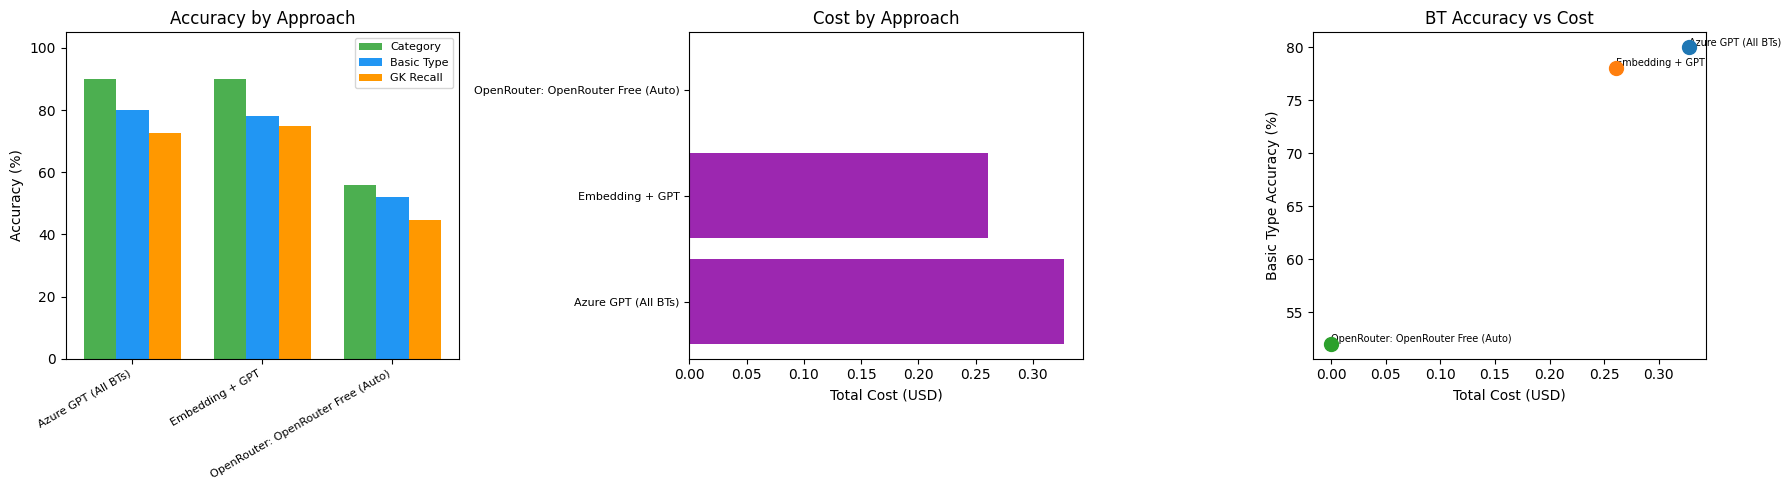

In [ ]:
# =============================================================================
# CELL 11: Visualization — Accuracy vs Cost Charts
# =============================================================================
import matplotlib.pyplot as plt

if len(summary_df) > 0 and summary_df["Cat Acc (%)"].apply(lambda x: isinstance(x, (int, float))).any():
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Filter to approaches that have numeric accuracy
    plot_df = summary_df[summary_df["Cat Acc (%)"].apply(lambda x: isinstance(x, (int, float)))].copy()

    # --- Chart 1: Accuracy comparison bar chart ---
    ax1 = axes[0]
    x = range(len(plot_df))
    w = 0.25
    ax1.bar([i - w for i in x], plot_df["Cat Acc (%)"], width=w, label="Category", color="#4CAF50")
    ax1.bar(x, plot_df["BT Acc (%)"], width=w, label="Basic Type", color="#2196F3")
    ax1.bar([i + w for i in x], plot_df["GK Recall (%)"], width=w, label="GK Recall", color="#FF9800")
    ax1.set_xticks(list(x))
    ax1.set_xticklabels(plot_df["Approach"], rotation=30, ha="right", fontsize=8)
    ax1.set_ylabel("Accuracy (%)")
    ax1.set_title("Accuracy by Approach")
    ax1.legend(fontsize=8)
    ax1.set_ylim(0, 105)

    # --- Chart 2: Cost comparison ---
    ax2 = axes[1]
    ax2.barh(plot_df["Approach"], plot_df["Total $"], color="#9C27B0")
    ax2.set_xlabel("Total Cost (USD)")
    ax2.set_title("Cost by Approach")
    ax2.tick_params(axis="y", labelsize=8)

    # --- Chart 3: Scatter — BT Accuracy vs Cost ---
    ax3 = axes[2]
    for _, row in plot_df.iterrows():
        ax3.scatter(row["Total $"], row["BT Acc (%)"], s=100, zorder=5)
        ax3.annotate(row["Approach"], (row["Total $"], row["BT Acc (%)"]),
                     fontsize=7, ha="left", va="bottom")
    ax3.set_xlabel("Total Cost (USD)")
    ax3.set_ylabel("Basic Type Accuracy (%)")
    ax3.set_title("BT Accuracy vs Cost")

    plt.tight_layout()
    plt.show()
else:
    print("No numeric results to plot yet.")

In [ ]:
# =============================================================================
# CELL 12: Export Detailed Results per Approach (with ground truth + pass/fail/blank)
# =============================================================================
# For each approach, builds a detailed DataFrame merging ground truth with
# predictions, showing PASS/FAIL/BLANK for Category & BT, and Missing/Extra GKs.
# Saves to benchmark_predictions/ and displays inline.

export_dir = os.path.join(TESTING_DATA_DIR, "benchmark_predictions")
os.makedirs(export_dir, exist_ok=True)

for key, ar in all_results.items():
    if not ar.predictions:
        continue

    ev = evaluation_results.get(key)
    if not ev:
        continue

    # Build detailed DataFrame from per_sku evaluation data
    detail_rows = []
    for sku_ev in ev["per_sku"]:
        detail_rows.append({
            "SKU Name": sku_ev["SKU"],
            # --- Category ---
            "Expected Category": sku_ev["Expected Cat"],
            "Predicted Category": sku_ev["Predicted Cat"],
            "Category Result": sku_ev["Cat Status"],
            # --- Basic Type ---
            "Expected Basic Type": sku_ev["Expected BT"],
            "Predicted Basic Type": sku_ev["Predicted BT"],
            "BT Result": sku_ev["BT Status"],
            # --- Generic Keywords ---
            "GK Recall (%)": sku_ev["GK Recall (%)"],
            "Missing GKs": ", ".join(sku_ev["Missing GKs"]) if sku_ev["Missing GKs"] else "",
            "Extra GKs": ", ".join(sku_ev["Extra GKs"]) if sku_ev["Extra GKs"] else "",
        })

    detail_df = pd.DataFrame(detail_rows)

    # --- Print inline summary + table ---
    _ev_summary = evaluation_results[key]
    print(f"\n{'='*80}")
    print(f"📊 {ar.approach_name}  |  Cat: {_ev_summary['category_accuracy']}%  |  BT: {_ev_summary['basic_type_accuracy']}%  |  GK: {_ev_summary['avg_gk_recall']}%")
    print(f"{'='*80}")

    # Show pass/fail/blank counts
    cat_pass = detail_df["Category Result"].str.contains("PASS").sum()
    cat_blank = detail_df["Category Result"].str.contains("BLANK").sum()
    bt_pass = detail_df["BT Result"].str.contains("PASS").sum()
    bt_blank = detail_df["BT Result"].str.contains("BLANK").sum()
    total = len(detail_df)
    print(f"  Category: {cat_pass}/{total} passed, {cat_blank} blank  |  Basic Type: {bt_pass}/{total} passed, {bt_blank} blank")
    if _ev_summary.get('blank_count', 0) > 0:
        print(f"  BT accuracy (excl blanks): {_ev_summary['bt_acc_excl_blank']}%")

    # Display with pandas styling for readability
    with pd.option_context('display.max_colwidth', 60, 'display.max_rows', None, 'display.width', None):
        display(detail_df)

    # --- Save to CSV ---
    fname = f"{key}_predictions.csv"
    detail_df.to_csv(os.path.join(export_dir, fname), index=False, encoding="utf-8")
    print(f"  💾 Saved: {fname} ({len(detail_df)} rows)")

print(f"\n✅ All detailed predictions exported to {export_dir}")


📊 Azure GPT (All BTs)  |  Cat: 90.0%  |  BT: 80.0%  |  GK: 72.77%
  Category: 45/50 passed, 0 blank  |  Basic Type: 40/50 passed, 0 blank


,SKU Name,Expected Category,Predicted Category,Category Result,Expected Basic Type,Predicted Basic Type,BT Result,GK Recall (%),Missing GKs,Extra GKs
0,Fontana Pomegranate Juice 1l,Groceries,Groceries,✅ PASS,Fruit Drink,Pomegranate Juice,❌ FAIL,0.0,"Juice, Fontana, Groceries, Fruit Drink, Fontana Pomegran...",
1,Kids Joy Baby Lanundry Detergent 1l,Baby Care,Baby Care,✅ PASS,Baby Detergent Liquid,Baby Detergent Liquid,✅ PASS,100.0,,Baby Laundry
2,Marvel Lady Tampons 10s,Personal Care,Personal Care,✅ PASS,Tampons,Tampons,✅ PASS,75.0,Marvel Tampons,
3,Keells Krest Jumbo Peanut Chilli 100G,Groceries,Groceries,✅ PASS,Peanuts,Jumbo Peanuts,❌ FAIL,14.3,"Groceries, Keels Peanuts, Chilli Peanuts, Keells Krest P...",Hot and Spicy Jumbo Peanuts
4,Finch Gourment Turkish Dried Figs 75g,Groceries,Groceries,✅ PASS,Dried Fruit,Dried Fruit,✅ PASS,100.0,,
5,Fortune Biriyani Special Basmathi Rice 1kg,Groceries,Groceries,✅ PASS,Basmathi Rice,Basmathi Rice,✅ PASS,100.0,,
6,Maped Color Pencil Box-color Peps 12,Stationery,Stationery,✅ PASS,Colour Pencil,Colour Pencil,✅ PASS,100.0,,
7,Mas Roasted Curry Powder 100g,Groceries,Groceries,✅ PASS,Curry Powder,Roasted Curry Powder,❌ FAIL,0.0,"Spices, Groceries, Roasted Curry Powder, Curry Powder, M...",
8,Mister Potato Original 145G,Groceries,Groceries,✅ PASS,Potato Chips,Potato Chips,✅ PASS,100.0,,"Chips, Snacks"
9,Kotmale Cheese Slices 200g,Dairy,Dairy,✅ PASS,Cheese Slices,Cheese Slices,✅ PASS,100.0,,


  💾 Saved: azure_gpt_all_bts_predictions.csv (50 rows)

📊 Embedding + GPT  |  Cat: 90.0%  |  BT: 78.0%  |  GK: 74.92%
  Category: 45/50 passed, 0 blank  |  Basic Type: 39/50 passed, 0 blank


,SKU Name,Expected Category,Predicted Category,Category Result,Expected Basic Type,Predicted Basic Type,BT Result,GK Recall (%),Missing GKs,Extra GKs
0,Fontana Pomegranate Juice 1l,Groceries,Groceries,✅ PASS,Fruit Drink,Mixed Fruit Juice,❌ FAIL,33.3,"Fontana, Fruit Drink, Pomegranate Juice, Fontana Pomegra...",Mixed Fruit Juice
1,Kids Joy Baby Lanundry Detergent 1l,Baby Care,Baby Care,✅ PASS,Baby Detergent Liquid,Baby Detergent Liquid,✅ PASS,100.0,,"Baby Laundry, Baby Laundry Wash"
2,Marvel Lady Tampons 10s,Personal Care,Personal Care,✅ PASS,Tampons,Tampons,✅ PASS,75.0,Marvel Tampons,
3,Keells Krest Jumbo Peanut Chilli 100G,Groceries,Groceries,✅ PASS,Peanuts,Jumbo Peanuts,❌ FAIL,28.6,"Keels Peanuts, Chilli Peanuts, Keells Krest Peanuts, Nut...",Hot and Spicy Jumbo Peanuts
4,Finch Gourment Turkish Dried Figs 75g,Groceries,Groceries,✅ PASS,Dried Fruit,Dried Fruit,✅ PASS,100.0,,
5,Fortune Biriyani Special Basmathi Rice 1kg,Groceries,Groceries,✅ PASS,Basmathi Rice,Basmathi Rice,✅ PASS,100.0,,
6,Maped Color Pencil Box-color Peps 12,Stationery,Stationery,✅ PASS,Colour Pencil,Colour Pencil,✅ PASS,100.0,,
7,Mas Roasted Curry Powder 100g,Groceries,Groceries,✅ PASS,Curry Powder,Curry Powder,✅ PASS,80.0,Spices,
8,Mister Potato Original 145G,Groceries,Groceries,✅ PASS,Potato Chips,Potato Chips,✅ PASS,100.0,,"Chips, Snacks"
9,Kotmale Cheese Slices 200g,Dairy,Dairy,✅ PASS,Cheese Slices,Cheese Slices,✅ PASS,100.0,,


  💾 Saved: embedding_plus_gpt_predictions.csv (50 rows)

📊 OpenRouter: OpenRouter Free (Auto)  |  Cat: 56.0%  |  BT: 52.0%  |  GK: 44.5%
  Category: 28/50 passed, 15 blank  |  Basic Type: 26/50 passed, 15 blank
  BT accuracy (excl blanks): 74.29%


,SKU Name,Expected Category,Predicted Category,Category Result,Expected Basic Type,Predicted Basic Type,BT Result,GK Recall (%),Missing GKs,Extra GKs
0,Fontana Pomegranate Juice 1l,Groceries,,⬜ BLANK,Fruit Drink,,⬜ BLANK,0.0,"Juice, Fontana, Groceries, Fruit Drink, Fontana Pomegran...",
1,Kids Joy Baby Lanundry Detergent 1l,Baby Care,,⬜ BLANK,Baby Detergent Liquid,,⬜ BLANK,0.0,"Baby Care, Baby Detergent Liquid, Kids Joy Baby Lanundry...",
2,Marvel Lady Tampons 10s,Personal Care,,⬜ BLANK,Tampons,,⬜ BLANK,0.0,"Personal Care, Tampons, Marvel Lady Tampons, Marvel Tampons",
3,Keells Krest Jumbo Peanut Chilli 100G,Groceries,,⬜ BLANK,Peanuts,,⬜ BLANK,0.0,"Jumbo Peanuts, Keels Peanuts, Groceries, Peanuts, Chilli...",
4,Finch Gourment Turkish Dried Figs 75g,Groceries,,⬜ BLANK,Dried Fruit,,⬜ BLANK,0.0,"Dried Fruit, Groceries, Finch Dried Figs, Dried Figs",
5,Fortune Biriyani Special Basmathi Rice 1kg,Groceries,,⬜ BLANK,Basmathi Rice,,⬜ BLANK,0.0,"Basmathi Rice, Groceries, Fortune Basmati Rice, Fortune ...",
6,Maped Color Pencil Box-color Peps 12,Stationery,,⬜ BLANK,Colour Pencil,,⬜ BLANK,0.0,"Stationery, Colour Pencil, Maped Colour Pencils",
7,Mas Roasted Curry Powder 100g,Groceries,,⬜ BLANK,Curry Powder,,⬜ BLANK,0.0,"Spices, Groceries, Roasted Curry Powder, Curry Powder, M...",
8,Mister Potato Original 145G,Groceries,,⬜ BLANK,Potato Chips,,⬜ BLANK,0.0,"Mister Potato Original, Groceries, Potato Chips, Mister ...",
9,Kotmale Cheese Slices 200g,Dairy,,⬜ BLANK,Cheese Slices,,⬜ BLANK,0.0,"Cheese Slices, Dairy, Kotmale Cheese Slices, Cheese, Kot...",


PermissionError: [Errno 13] Permission denied: 'c:\\Code\\AI Tagging\\streamlit_app\\Testing Data\\benchmark_predictions\\openrouter_openrouter_auto_predictions.csv'

In [ ]:
# =========================
# CHECK TAGGING ACCURACY
# =========================
import pandas as pd

# CONFIG: File names (edit these as needed)
RESULT_FILE = "tagging_results.csv"  # File with tagging results
SAMPLE_FILE = "Catalog_SKUs_TestSample_10.csv"  # File with catalog sample

# Load the result and sample files
result_path = os.path.join(os.path.dirname(input_path), RESULT_FILE)
sample_path = os.path.join(os.path.dirname(input_path), SAMPLE_FILE)

result_df = pd.read_csv(result_path)
sample_df = pd.read_csv(sample_path)

# Normalize column names for consistency
result_df.columns = [c.strip().lower() for c in result_df.columns]
sample_df.columns = [c.strip().lower() for c in sample_df.columns]

# Ensure required columns exist
required_sample_columns = {"name", "categories", "basic type", "generic keywords"}
required_result_columns = {"sku name", "category", "basic type", "generic keywords"}

if not required_sample_columns.issubset(sample_df.columns):
    raise ValueError(f"Sample file must contain columns: {required_sample_columns}")

if not required_result_columns.issubset(result_df.columns):
    raise ValueError(f"Result file must contain columns: {required_result_columns}")

# Check tagging accuracy
accuracy_report = []
category_correct_count = 0
basic_type_correct_count = 0

for _, row in sample_df.iterrows():
    sku_name = row["name"]
    expected_category = row["categories"]
    expected_bt = row["basic type"]
    expected_gks = set(row["generic keywords"].strip("[]").replace("'", "").split(", "))

    # Find the corresponding result row
    result_row = result_df[result_df["sku name"] == sku_name]

    if result_row.empty:
        accuracy_report.append({
            "SKU": sku_name,
            "Category Correct": False,
            "Basic Type Correct": False,
            "Expected Category": expected_category,
            "Result Category": None,
            "Expected Basic Type": expected_bt,
            "Result Basic Type": None,
            "Missing GKs": list(expected_gks),
            "Extra GKs": [],
            "GK Accuracy (%)": 0.0
        })
        continue

    result_category = result_row.iloc[0]["category"]
    result_bt = result_row.iloc[0]["basic type"]
    result_gks = set(result_row.iloc[0]["generic keywords"].strip("[]").replace("'", "").split(", "))

    missing_gks = expected_gks - result_gks
    extra_gks = result_gks - expected_gks
    gk_accuracy = (len(expected_gks & result_gks) / len(expected_gks)) * 100 if expected_gks else 100.0

    category_correct = result_category == expected_category
    basic_type_correct = result_bt == expected_bt

    if category_correct:
        category_correct_count += 1
    if basic_type_correct:
        basic_type_correct_count += 1

    accuracy_report.append({
        "SKU": sku_name,
        "Category Correct": category_correct,
        "Basic Type Correct": basic_type_correct,
        "Expected Category": expected_category,
        "Result Category": result_category,
        "Expected Basic Type": expected_bt,
        "Result Basic Type": result_bt,
        "Missing GKs": list(missing_gks),
        "Extra GKs": list(extra_gks),
        "GK Accuracy (%)": gk_accuracy
    })

# Convert accuracy report to DataFrame
accuracy_df = pd.DataFrame(accuracy_report)

# Calculate overall accuracy
total_records = len(sample_df)
category_accuracy = (category_correct_count / total_records) * 100
basic_type_accuracy = (basic_type_correct_count / total_records) * 100

# Print summary results
print("\n=========================")
print("TAGGING ACCURACY SUMMARY")
print("=========================")
print(f"Total Records: {total_records}")
print(f"Category Accuracy: {category_accuracy:.2f}%")
print(f"Basic Type Accuracy: {basic_type_accuracy:.2f}%")
print("\nDetailed Results:")
print(accuracy_df)

# Save the accuracy report
accuracy_report_path = os.path.join(os.path.dirname(input_path), "Tagging_Accuracy_Report.csv")
accuracy_df.to_csv(accuracy_report_path, index=False, encoding="utf-8")

print("\n✅ Tagging accuracy report saved to:", accuracy_report_path)

NameError: name 'input_path' is not defined